## Imports

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [9]:
all_data = pd.read_csv('data/all_models_comparison.csv')

all_data = all_data.rename(columns={'model': 'method'})

def classify_method(method):
    if 'TF-IDF' in method:
        return 'Baseline'
    elif 'ensemble-rag' in method:
        return 'Baseline'
    else:
        return 'Embeddings'

all_data['method_type'] = all_data['method'].apply(classify_method)

print("Data loaded and prepared:")
print(all_data.head())
print(f"\nTotal methods: {len(all_data)}")

Data loaded and prepared:
                    method     classifier  accuracy  f1_macro  \
0     TF-IDF (5k features)    Naive Bayes  0.677383  0.677211   
1     TF-IDF (5k features)  Random Forest  0.686358  0.685258   
2     TF-IDF (5k features)            SVM  0.695496  0.695042   
3     TF-IDF (5k features)       LightGBM  0.699902  0.699842   
4  TF-IDF (1-3 grams, 10k)             LR  0.714300  0.714363   

   precision_macro  recall_macro method_type  
0         0.683854      0.676368    Baseline  
1         0.690790      0.685299    Baseline  
2         0.697433      0.694859    Baseline  
3         0.701068      0.699466    Baseline  
4         0.716464      0.713836    Baseline  

Total methods: 18


In [12]:
all_data.head()

,method,classifier,accuracy,f1_macro,precision_macro,recall_macro,method_type
0,TF-IDF (5k features),Naive Bayes,0.677383,0.677211,0.683854,0.676368,Baseline
1,TF-IDF (5k features),Random Forest,0.686358,0.685258,0.690790,0.685299,Baseline
2,TF-IDF (5k features),SVM,0.695496,0.695042,0.697433,0.694859,Baseline
3,TF-IDF (5k features),LightGBM,0.699902,0.699842,0.701068,0.699466,Baseline
4,"TF-IDF (1-3 grams, 10k)",LR,0.714300,0.714363,0.716464,0.713836,Baseline


### PLOT 1: Ranked Bar Chart - All Methods

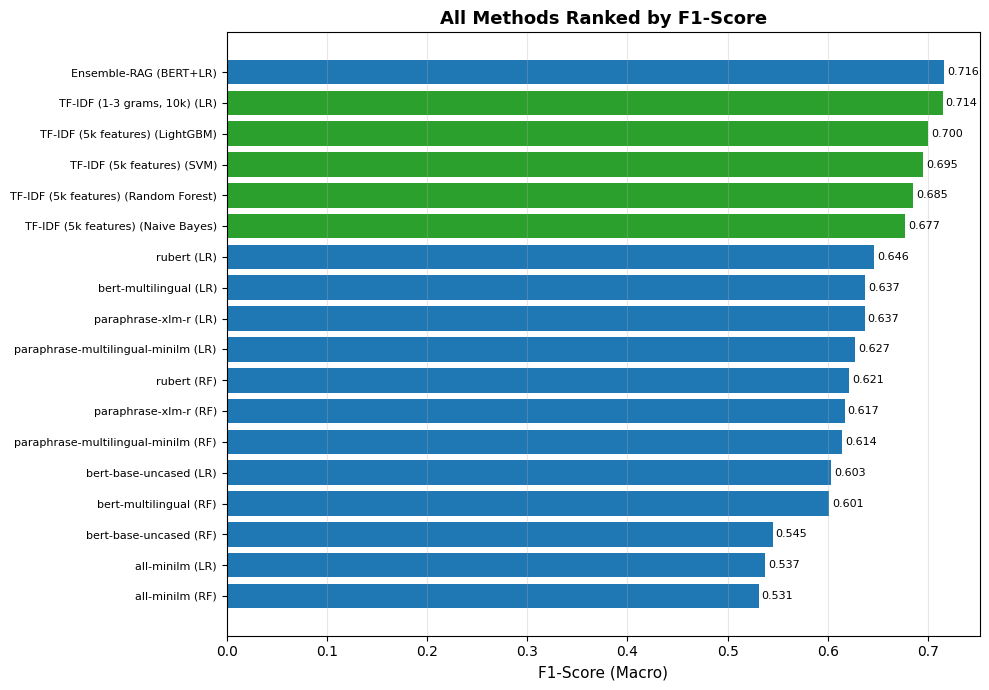

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

sorted_data = all_data.sort_values('f1_macro', ascending=True)
colors = ['#2ca02c' if 'TF-IDF' in m else '#ff7f0e' if 'Unigrams' in m else '#1f77b4' 
          for m in sorted_data['method']]

ax.barh(range(len(sorted_data)), sorted_data['f1_macro'], color=colors)
ax.set_yticks(range(len(sorted_data)))
ax.set_yticklabels([f"{m} ({c})" for m, c in zip(sorted_data['method'], sorted_data['classifier'])], fontsize=8)
ax.set_xlabel('F1-Score (Macro)', fontsize=11)
ax.set_title('All Methods Ranked by F1-Score', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

for i, v in enumerate(sorted_data['f1_macro']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plots/plot1_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 2: Grouped Bar - Top 5 with All Metricsx

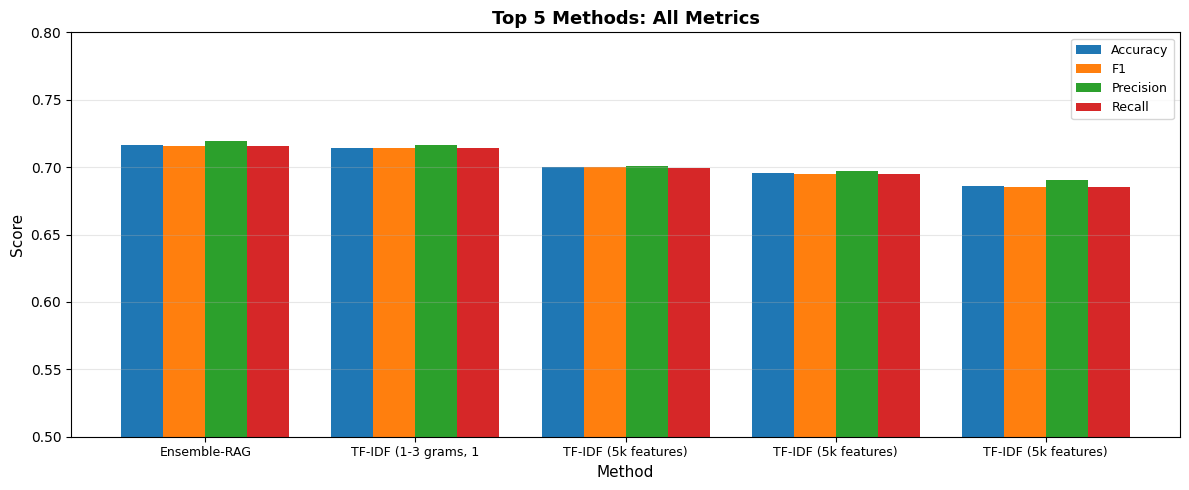

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

top5 = all_data.nlargest(5, 'f1_macro')
metrics = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
x = np.arange(len(top5))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i*width - 1.5*width, top5[metric], width, 
           label=metric.replace('_macro', '').replace('_', ' ').title())

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Top 5 Methods: All Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{m[:20]}" for m in top5['method']], fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.5, 0.8)

plt.tight_layout()
plt.savefig('plots/plot2_top5_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### PLOT 3: Heatmap - F1 Scores


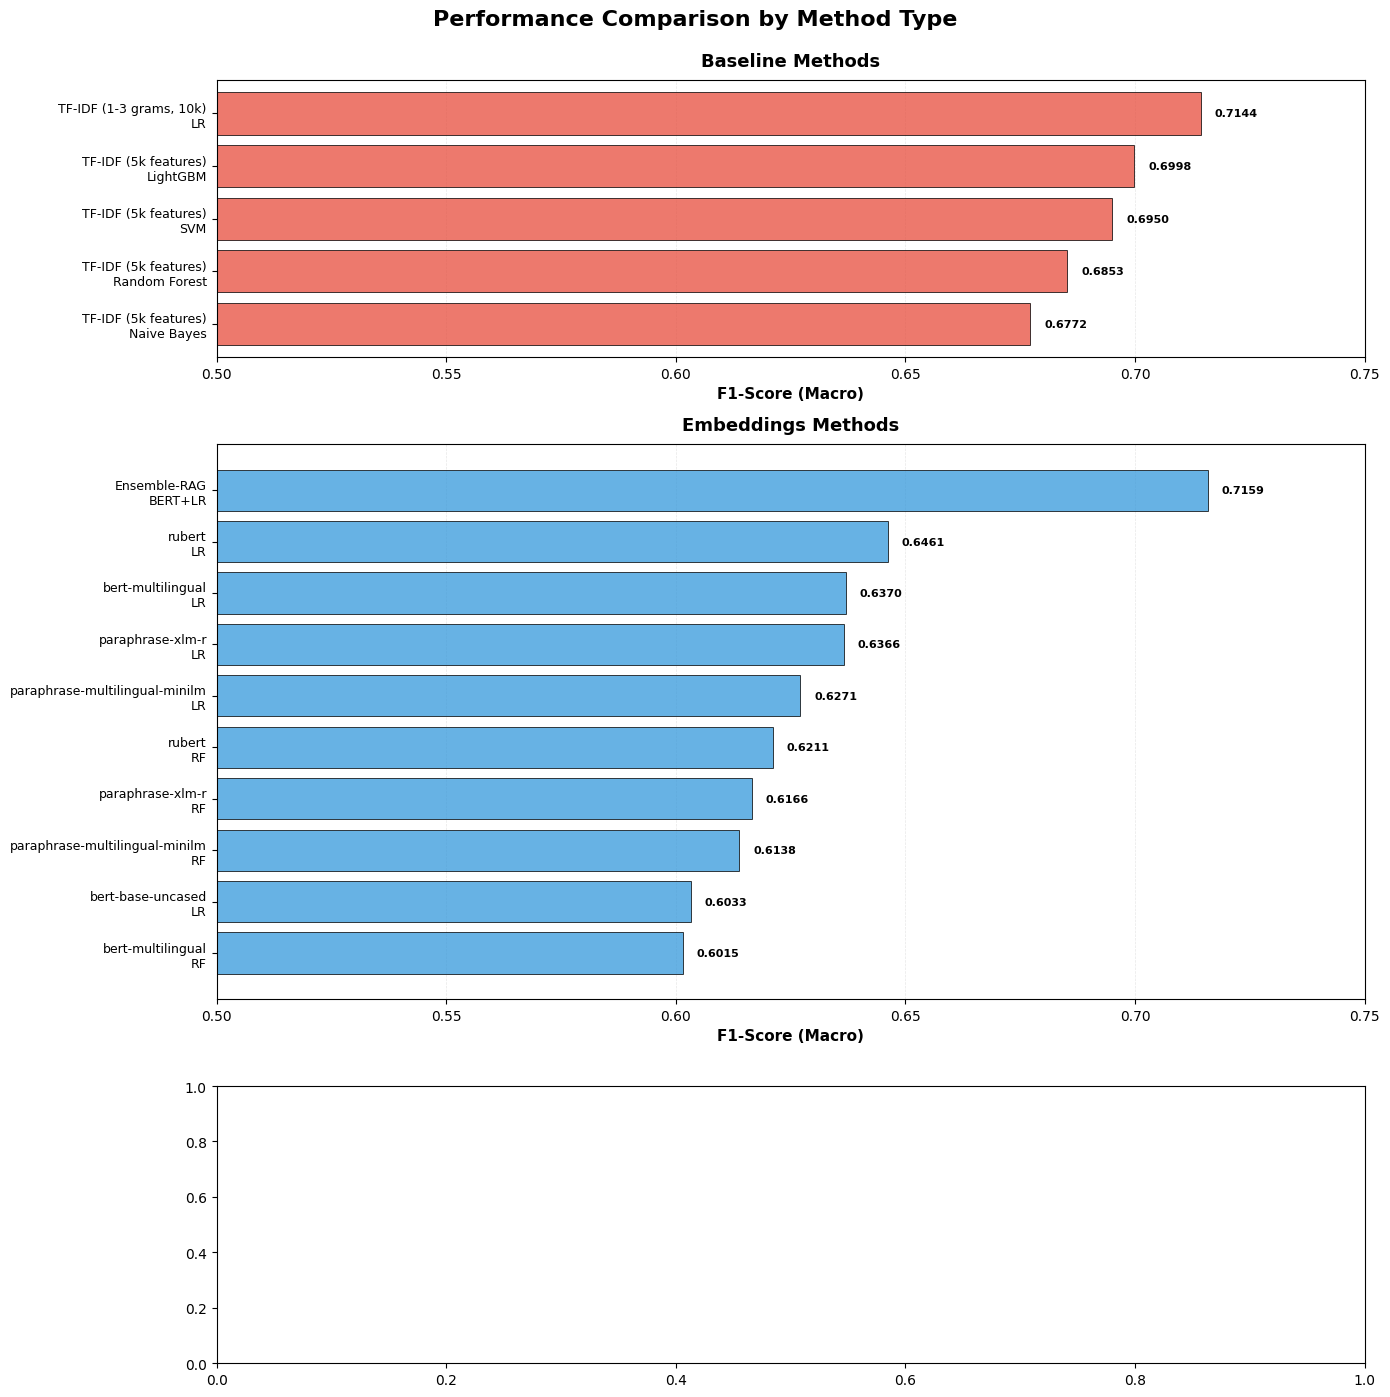

In [ ]:
# Separate subplots for each type
fig, axes = plt.subplots(3, 1, figsize=(14, 14), 
                         gridspec_kw={'height_ratios': [1, 2, 1]})

method_types = ['Baseline', 'Embeddings', 'Ensemble']
colors_map = {
    'Baseline': '#e74c3c',
    'Embeddings': '#3498db',
    'Ensemble': '#2ecc71'
}

for idx, mtype in enumerate(method_types):
    type_data = all_data[all_data['method_type'] == mtype].sort_values('f1_macro', ascending=True)
    
    if len(type_data) > 10:
        type_data = type_data.tail(10)
    
    if not type_data.empty:
        labels = [f"{row['method']}\n{row['classifier']}" 
                  for _, row in type_data.iterrows()]
        
        bars = axes[idx].barh(range(len(type_data)), 
                             type_data['f1_macro'],
                             color=colors_map[mtype],
                             alpha=0.75,
                             edgecolor='black',
                             linewidth=0.7)
        
        axes[idx].set_yticks(range(len(type_data)))
        axes[idx].set_yticklabels(labels, fontsize=9)
        axes[idx].set_xlabel('F1-Score (Macro)', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{mtype} Methods', fontsize=13, fontweight='bold', pad=10)
        axes[idx].grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
        axes[idx].set_axisbelow(True)
        
        # Add value labels
        for i, val in enumerate(type_data['f1_macro']):
            axes[idx].text(val + 0.003, i, f'{val:.4f}', 
                          va='center', ha='left', fontsize=8, fontweight='bold')
        
        # Consistent x-axis
        axes[idx].set_xlim(0.50, 0.75)

plt.suptitle('Performance Comparison by Method Type', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/plot3_grouped_by_type.png', dpi=300, bbox_inches='tight')
plt.show()


### PLOT 4: Scatter - Precision vs Recall

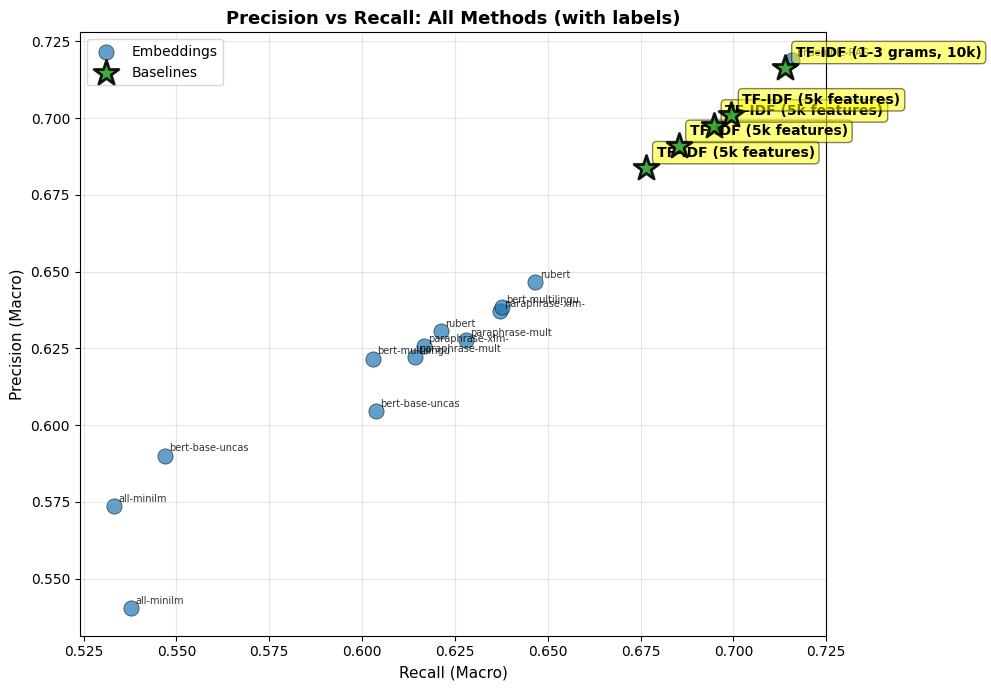

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

embeddings_subset = all_data[all_data['method_type'] == 'Embeddings']
ax.scatter(embeddings_subset['recall_macro'], embeddings_subset['precision_macro'], 
          s=120, alpha=0.7, label='Embeddings', marker='o', c='#1f77b4', edgecolors='black', linewidth=0.5)

for _, row in embeddings_subset.iterrows():
    ax.annotate(f"{row['method'][:15]}", 
               (row['recall_macro'], row['precision_macro']),
               xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8)

baselines_subset = all_data[all_data['method_type'] == 'Baseline']
ax.scatter(baselines_subset['recall_macro'], baselines_subset['precision_macro'], 
          s=350, alpha=0.9, label='Baselines', marker='*', c='#2ca02c', edgecolors='black', linewidth=2, zorder=10)

for _, row in baselines_subset.iterrows():
    ax.annotate(row['method'], 
               (row['recall_macro'], row['precision_macro']),
               xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Recall (Macro)', fontsize=11)
ax.set_ylabel('Precision (Macro)', fontsize=11)
ax.set_title('Precision vs Recall: All Methods (with labels)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/plot4_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 5: Box Plot - Performance by Method Type

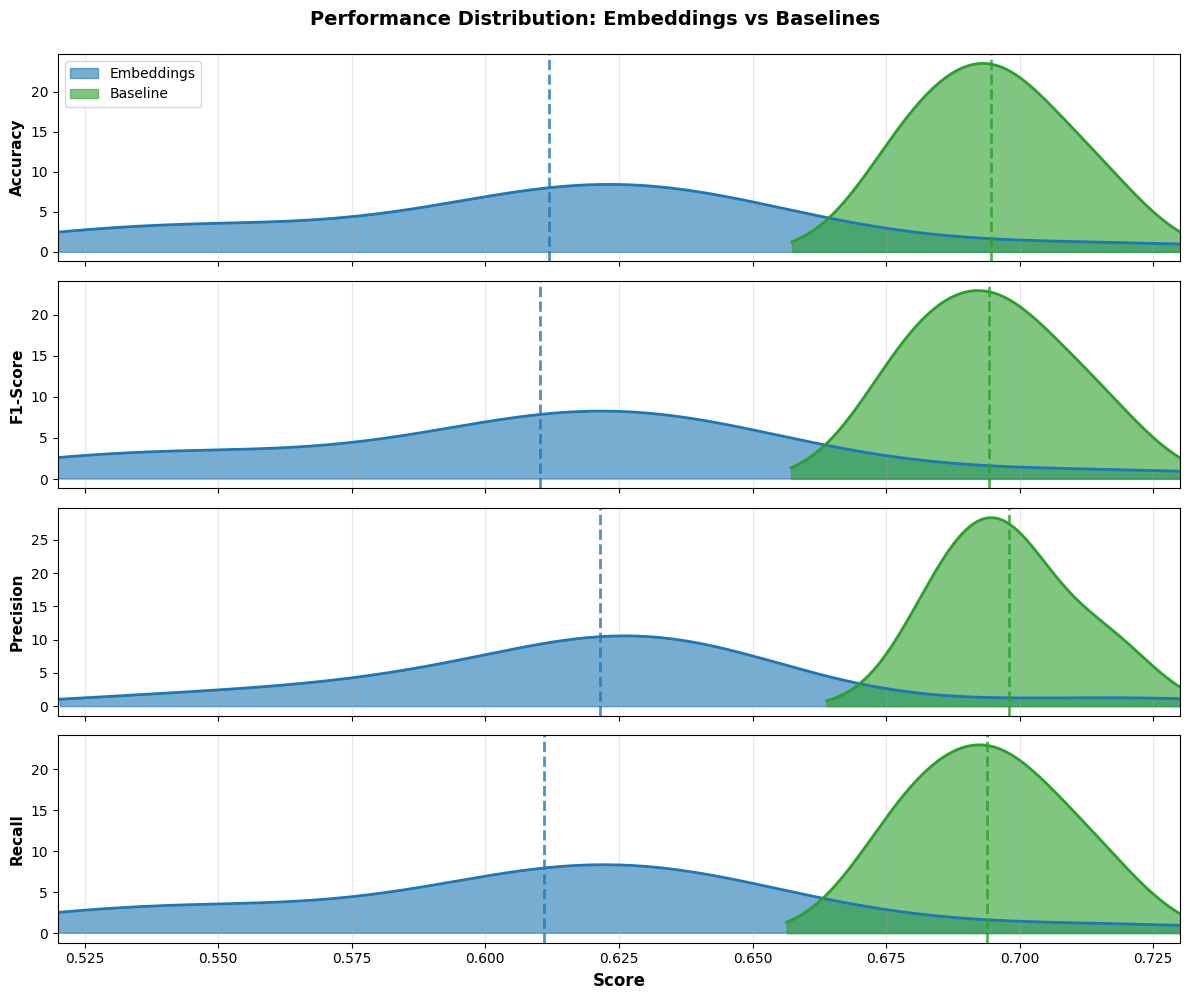

In [6]:

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

metrics = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall']

colors = {'Embeddings': '#1f77b4', 'Baseline': '#2ca02c'}

for ax, metric, label in zip(axes, metrics, metric_labels):
    for method_type in ['Embeddings', 'Baseline']:
        data = all_data[all_data['method_type'] == method_type][metric].dropna()
        
        if len(data) > 0:
            density = stats.gaussian_kde(data)
            xs = np.linspace(data.min() - 0.02, data.max() + 0.02, 200)
            ys = density(xs)
            
            ax.fill_between(xs, ys, alpha=0.6, color=colors[method_type], label=method_type)
            ax.plot(xs, ys, color=colors[method_type], linewidth=2)
            
            ax.axvline(data.mean(), color=colors[method_type], linestyle='--', 
                      linewidth=2, alpha=0.8)
    
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0.52, 0.73)
    
    if ax == axes[0]:
        ax.legend(loc='upper left', fontsize=10)

axes[-1].set_xlabel('Score', fontsize=12, fontweight='bold')
plt.suptitle('Performance Distribution: Embeddings vs Baselines', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/plot5_ridge_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### PLOT 6: Summary Table


[6] Summary table...


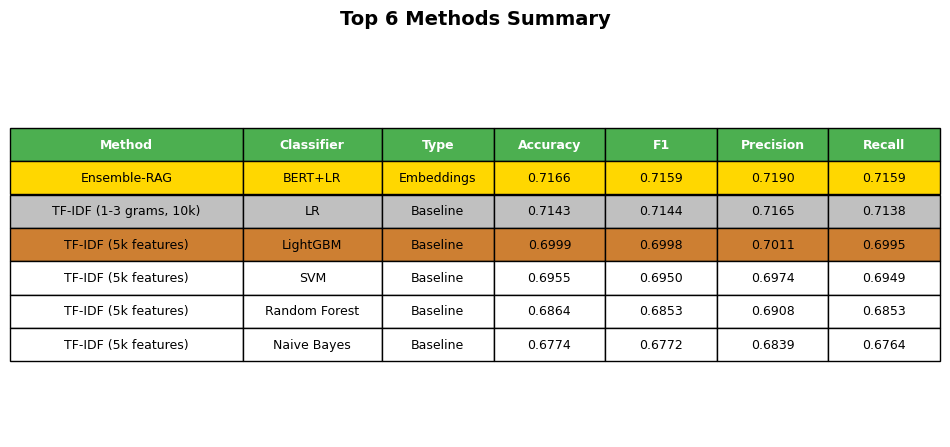

In [ ]:
print("\n[6] Summary table...")
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

summary_data = []
for _, row in all_data.nlargest(6, 'f1_macro').iterrows():
    summary_data.append([
        row['method'],
        row['classifier'],
        row['method_type'],
        f"{row['accuracy']:.4f}",
        f"{row['f1_macro']:.4f}",
        f"{row['precision_macro']:.4f}",
        f"{row['recall_macro']:.4f}"
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Method', 'Classifier', 'Type', 'Accuracy', 'F1', 'Precision', 'Recall'],
                cellLoc='center',
                loc='center',
                colWidths=[0.25, 0.15, 0.12, 0.12, 0.12, 0.12, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(7):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for row_idx in [1, 2, 3]:
    for col_idx in range(7):
        table[(row_idx, col_idx)].set_facecolor(['#FFD700', '#C0C0C0', '#CD7F32'][row_idx-1])

plt.title('Top 6 Methods Summary', fontsize=14, fontweight='bold', pad=20)
plt.savefig('plots/plot6_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
